In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [20]:
df = pd.read_csv("Course_Completion_Prediction.csv")
df.head()

,Student_ID,Name,Gender,Age,Education_Level,Employment_Status,City,Device_Type,Internet_Connection_Quality,Course_ID,...,Enrollment_Date,Payment_Mode,Fee_Paid,Discount_Used,Payment_Amount,App_Usage_Percentage,Reminder_Emails_Clicked,Support_Tickets_Raised,Satisfaction_Rating,Completed
0,STU100000,Vihaan Patel,Male,19,Diploma,Student,Indore,Laptop,Medium,C102,...,01-06-2024,Scholarship,No,No,1740,49,3,4,3.5,Completed
1,STU100001,Arjun Nair,Female,17,Bachelor,Student,Delhi,Laptop,Low,C106,...,27-04-2025,Credit Card,Yes,No,6147,86,0,0,4.5,Not Completed
2,STU100002,Aditya Bhardwaj,Female,34,Master,Student,Chennai,Mobile,Medium,C101,...,20-01-2024,NetBanking,Yes,No,4280,85,1,0,5.0,Completed
3,STU100003,Krishna Singh,Female,29,Diploma,Employed,Surat,Mobile,High,C105,...,13-05-2025,UPI,Yes,No,3812,42,2,3,3.8,Completed
4,STU100004,Krishna Nair,Female,19,Master,Self-Employed,Lucknow,Laptop,Medium,C106,...,19-12-2024,Debit Card,Yes,Yes,5486,91,3,0,4.0,Completed


In [21]:
df["target"] = df["Completed"].apply(lambda x: 1 if x == "Completed" else 0)

In [22]:
dropout_rate = 1 - df["target"].mean()
print("Dropout Rate:", dropout_rate)

Dropout Rate: 0.5097


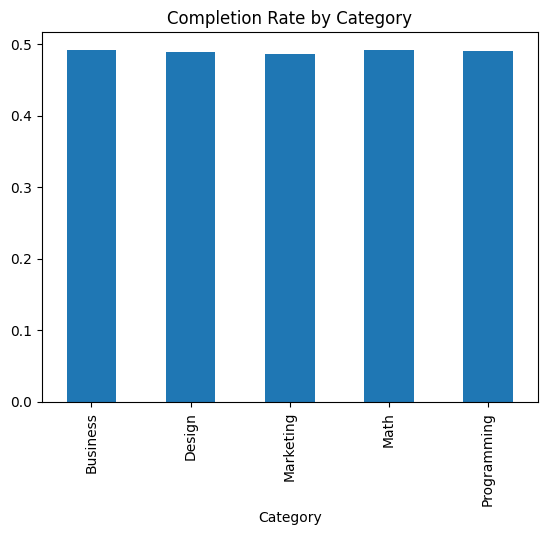

In [23]:
df.groupby("Category")["target"].mean().plot(kind="bar")
plt.title("Completion Rate by Category")
plt.show()

In [24]:
df.groupby("target")[[
    "Login_Frequency",
    "App_Usage_Percentage",
    "Video_Completion_Rate"
]].mean()

,Login_Frequency,App_Usage_Percentage,Video_Completion_Rate
target,,,
0,4.706886,67.435923,58.813439
1,4.866979,68.299857,65.668713


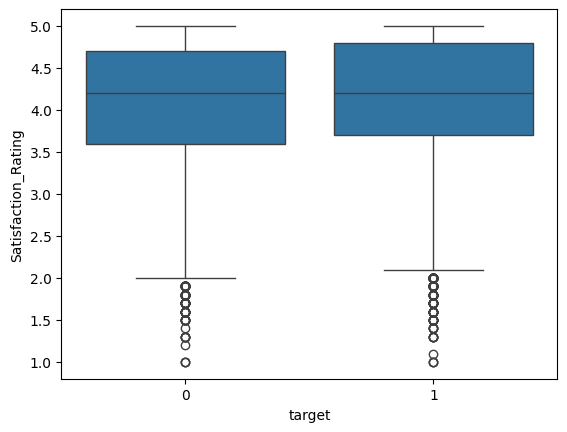

In [25]:
sns.boxplot(x="target", y="Satisfaction_Rating", data=df)
plt.show()

In [26]:
features = [
    "Login_Frequency",
    "App_Usage_Percentage",
    "Video_Completion_Rate",
    "Assignments_Submitted",
    "Assignments_Missed",
    "Days_Since_Last_Login",
    "Satisfaction_Rating"
]

X = df[features]
y = df["target"]

In [27]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [28]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier()
model.fit(X_train, y_train)

RandomForestClassifier()

In [29]:
y_pred = model.predict(X_test)

In [30]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.57      0.60      0.58     10138
           1       0.56      0.53      0.54      9862

    accuracy                           0.56     20000
   macro avg       0.56      0.56      0.56     20000
weighted avg       0.56      0.56      0.56     20000



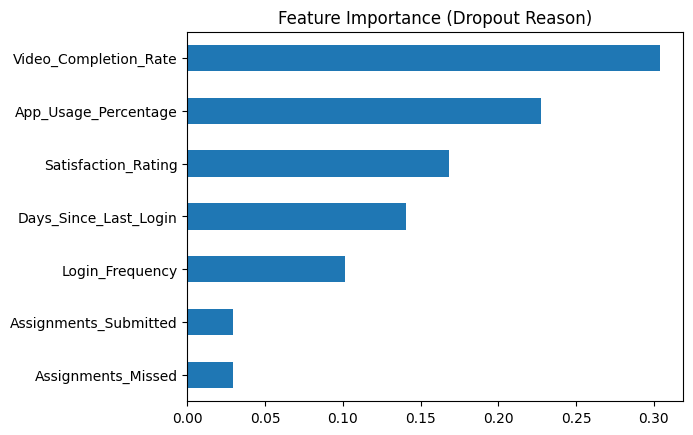

In [31]:
importance = pd.Series(model.feature_importances_, index=features)
importance.sort_values().plot(kind="barh")
plt.title("Feature Importance (Dropout Reason)")
plt.show()

In [32]:
df.to_csv("final_data.csv", index=False)